In [2]:
from pathlib import Path

import requests
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
DATASET_PAGE_URL = "https://open.toronto.ca/dataset/bike-share-toronto-ridership-data/"

DATA_URL = (
    "https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/"
    "7e876c24-177c-4605-9cef-e50dd74c617f/resource/"
    "85326868-508c-497e-b139-b698aaf27bbf/download/"
    "bikeshare-ridership-2014-2015.xlsx"
)

In [4]:

OUTPUT_DIR = Path.cwd()

if OUTPUT_DIR.name != "assignment_3":
    OUTPUT_DIR = OUTPUT_DIR / "assignment_3"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = OUTPUT_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "bikeshare-ridership-2014-2015.xlsx"
OUTPUT_PNG = OUTPUT_DIR / "visualization_1_python_hourly_trips.png"


In [5]:
def download_dataset() -> Path:
    if DATA_PATH.exists() and DATA_PATH.stat().st_size > 0:
        print("Dataset already exists. Using local file:")
        print(DATA_PATH)
        return DATA_PATH

    print("Downloading public dataset...")

    headers = {
        "User-Agent": "Mozilla/5.0 assignment-3-data-visualization",
        "Accept": (
            "application/vnd.openxmlformats-officedocument.spreadsheetml.sheet,"
            "application/vnd.ms-excel,*/*"
        ),
        "Referer": DATASET_PAGE_URL,
    }

    response = requests.get(DATA_URL, headers=headers, timeout=120)
    response.raise_for_status()

    DATA_PATH.write_bytes(response.content)

    print("Dataset downloaded to:")
    print(DATA_PATH)

    return DATA_PATH

In [6]:
def read_hourly_sheet(path: Path, sheet_name: str, day_type: str) -> pd.DataFrame:
    raw = pd.read_excel(
        path,
        sheet_name=sheet_name,
        header=None,
        engine="openpyxl",
    )

    # The real column names are in row index 1.
    raw.columns = raw.iloc[1].astype(str).str.strip()

    # Actual data starts after the title/header rows.
    df = raw.iloc[2:].dropna(how="all").copy()

    # Rename Start Time so it is easier to work with in Python.
    df = df.rename(columns={"Start Time": "start_time"})

    # Keep only hourly rows like 00:00-00:59, 01:00-01:59, etc.
    # This removes the final Total row.
    df = df[df["start_time"].astype(str).str.match(r"^\d{2}:\d{2}")].copy()

    # Convert trip count columns into numbers.
    for column in ["Casual", "Subscriber", "Total"]:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    # Create a numeric hour column from the start time text.
    df["hour"] = df["start_time"].astype(str).str.slice(0, 2).astype(int)

    # Add a label so we can compare weekday and weekend patterns.
    df["day_type"] = day_type

    return df[["hour", "start_time", "Casual", "Subscriber", "Total", "day_type"]]

In [7]:

def build_hourly_data(path: Path) -> pd.DataFrame:
    weekday = read_hourly_sheet(path, "Weekday Trips by Hour", "Weekday")
    weekend = read_hourly_sheet(path, "Weekend Trips by Hour", "Weekend")

    hourly = pd.concat([weekday, weekend], ignore_index=True)

    return hourly

Dataset already exists. Using local file:
/Users/eve/Downloads/visualization/assignment_3/data/bikeshare-ridership-2014-2015.xlsx
Cleaned hourly data preview:


1,hour,start_time,Casual,Subscriber,Total,day_type
0,0,00:00-00:59,1022,3694,4716,Weekday
1,1,01:00-01:59,574,1789,2363,Weekday
2,2,02:00-02:59,386,1037,1423,Weekday
3,3,03:00-03:59,267,586,853,Weekday
4,4,04:00-04:59,148,569,717,Weekday


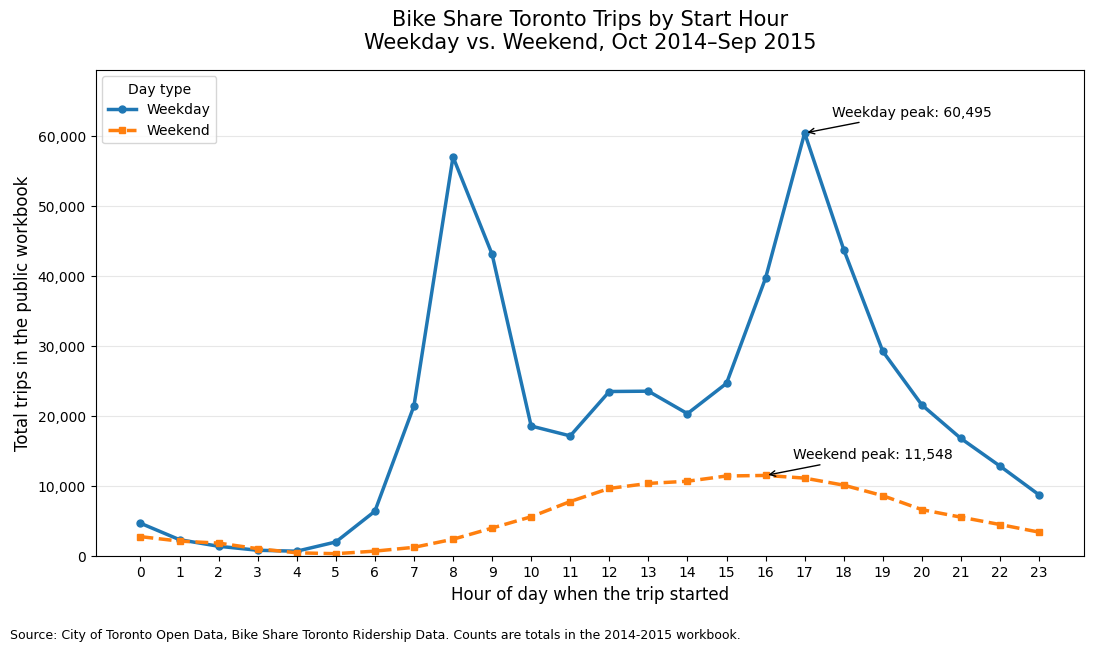

Saved visualization to:
/Users/eve/Downloads/visualization/assignment_3/visualization_1_python_hourly_trips.png


In [8]:

def make_python_hourly_plot(hourly: pd.DataFrame, output_path: Path) -> None:
    plt.figure(figsize=(11, 6.5))

    max_total = hourly["Total"].max()
    label_offset = max_total * 0.04

    for day_type, linestyle, marker in [
        ("Weekday", "-", "o"),
        ("Weekend", "--", "s"),
    ]:
        subset = hourly[hourly["day_type"] == day_type].sort_values("hour")

        plt.plot(
            subset["hour"],
            subset["Total"],
            linestyle=linestyle,
            marker=marker,
            linewidth=2.5,
            markersize=5,
            label=day_type,
        )

        # Mark the highest point for each line.
        peak = subset.loc[subset["Total"].idxmax()]

        plt.annotate(
            f"{day_type} peak: {int(peak['Total']):,}",
            xy=(peak["hour"], peak["Total"]),
            xytext=(peak["hour"] + 0.7, peak["Total"] + label_offset),
            arrowprops={"arrowstyle": "->", "linewidth": 1},
            fontsize=10,
        )

    plt.ylim(0, max_total * 1.15)

    plt.title(
        "Bike Share Toronto Trips by Start Hour\nWeekday vs. Weekend, Oct 2014–Sep 2015",
        fontsize=15,
        pad=15,
    )

    plt.xlabel("Hour of day when the trip started", fontsize=12)
    plt.ylabel("Total trips in the public workbook", fontsize=12)

    plt.xticks(range(0, 24))

    # Format y-axis numbers with commas.
    plt.gca().yaxis.set_major_formatter(lambda value, _: f"{int(value):,}")

    plt.grid(axis="y", alpha=0.3)
    plt.legend(title="Day type")

    plt.figtext(
        0.01,
        0.01,
        "Source: City of Toronto Open Data, Bike Share Toronto Ridership Data. Counts are totals in the 2014-2015 workbook.",
        ha="left",
        fontsize=9,
    )

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig(output_path, dpi=220)
    plt.show()

    print("Saved visualization to:")
    print(output_path)


data_path = download_dataset()

hourly = build_hourly_data(data_path)

print("Cleaned hourly data preview:")
display(hourly.head())

make_python_hourly_plot(hourly, OUTPUT_PNG)